# Statistical Modelling — ARIMA, Holt-Winters, and Prophet
### Goal: Model unit_sales using three different forecasting approaches on a feature-rich dataset

---

This notebook uses the expanded feature-engineered dataset built in the Feature Engineering notebook.  
It covers three models side by side so you can understand how each one works, what features it needs, and how to evaluate them on the same data.

### What is in the dataset?

The dataset contains **452 days** of daily unit sales (January 2013 – March 2014) along with 24 features:

| Feature group | Columns |
|---|---|
| **Target** | `unit_sales` |
| **External signal** | `dcoilwtico` (crude oil price) |
| **Holiday flags** | `is_national_holiday`, `is_regional_holiday`, `is_local_holiday` |
| **Calendar** | `year`, `month`, `day`, `dayofweek`, `quarter`, `week_of_year`, `is_weekend`, `is_month_start`, `is_month_end` |
| **Lag features** | `lag_1`, `lag_7`, `lag_14`, `lag_30` |
| **Rolling features** | `rolling_7d_mean`, `rolling_14d_mean`, `rolling_30d_mean`, `rolling_7d_std` |
| **Oil lags** | `oil_lag_1`, `oil_rolling_7d_mean` |

### The three models

| Model | Type | What it uses from the dataset |
|---|---|---|
| **ARIMA / SARIMAX** | Statistical | Target series + external regressors (oil, holidays) |
| **Holt-Winters** | Statistical | Target series only — no external features |
| **Prophet** | Bayesian curve-fitting | Target series + holiday flags + regressors |

### Notebook structure

1. Install and import libraries
2. Load and prepare the dataset
3. Explore the data and feature importance
4. Train / test split
5. **ARIMA / SARIMAX** — preparation, features, factors, evaluation
6. **Holt-Winters** — preparation, features, factors, evaluation
7. **Prophet** — preparation, features, factors, evaluation
8. Model performance comparison

---
## Step 1 — Install Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn prophet

---
## Step 2 — Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels — ARIMA and Holt-Winters
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# Scikit-learn — feature importance and evaluation metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

c:\Users\alipa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


All libraries imported successfully!


---
## Step 3 — Load the Dataset

We load the feature-engineered CSV that was built in the Feature Engineering notebook.  
If you ran the Feature Engineering notebook in this session, you can also retrieve it with:
```python
%store -r df
```
Otherwise, load it from the CSV file below.

In [ ]:
# Set the path to your data folder
DATA_DIR = 'C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\\Data'

# Load the feature-engineered dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date (important for time series)
df = df.sort_values('date').reset_index(drop=True)

print("Dataset loaded successfully!")
print("Shape of the dataframe:", df.shape)                # Check the shape of the dataframe
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())  # Check the date range
print("Number of rows:", len(df))                       # Check the number of rows
print("Columns in the dataframe:", list(df.columns))     # Check the columns in the dataframe

Dataset loaded successfully!
Shape of the dataframe: (452, 25)
Date range: 2013-01-02 to 2014-03-31
Number of rows: 452
Columns in the dataframe: ['date', 'unit_sales', 'dcoilwtico', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'oil_lag_1', 'oil_rolling_7d_mean']


In [ ]:
# Preview the data

print("First few rows of the dataframe:")
print(df.head())                                   # View the first few rows of the dataframe      
print("Missing values in the dataframe:")
print(df.isnull().sum()[df.isnull().sum() > 0])    # Check for missing values in the dataframe

First few rows of the dataframe:
        date  unit_sales  dcoilwtico  is_national_holiday  \
0 2013-01-02       582.0   93.140000                    0   
1 2013-01-03       310.0   92.970000                    0   
2 2013-01-04       338.0   93.120000                    0   
3 2013-01-05       654.0   93.146667                    1   
4 2013-01-06       979.0   93.173333                    0   

   is_regional_holiday  is_local_holiday  year  month  day  dayofweek  ...  \
0                    0                 0  2013      1    2          2  ...   
1                    0                 0  2013      1    3          3  ...   
2                    0                 0  2013      1    4          4  ...   
3                    0                 0  2013      1    5          5  ...   
4                    0                 0  2013      1    6          6  ...   

   lag_1  lag_7  lag_14  lag_30  rolling_7d_mean  rolling_14d_mean  \
0    NaN    NaN     NaN     NaN              NaN             

---
## Step 4 — Explore the Data

Before modelling, we need to understand the data visually and statistically.  
This section covers:
- The overall shape of unit_sales over time
- The distribution of sales values
- Which features are most correlated with unit_sales
- Whether the series is stationary (required for ARIMA)

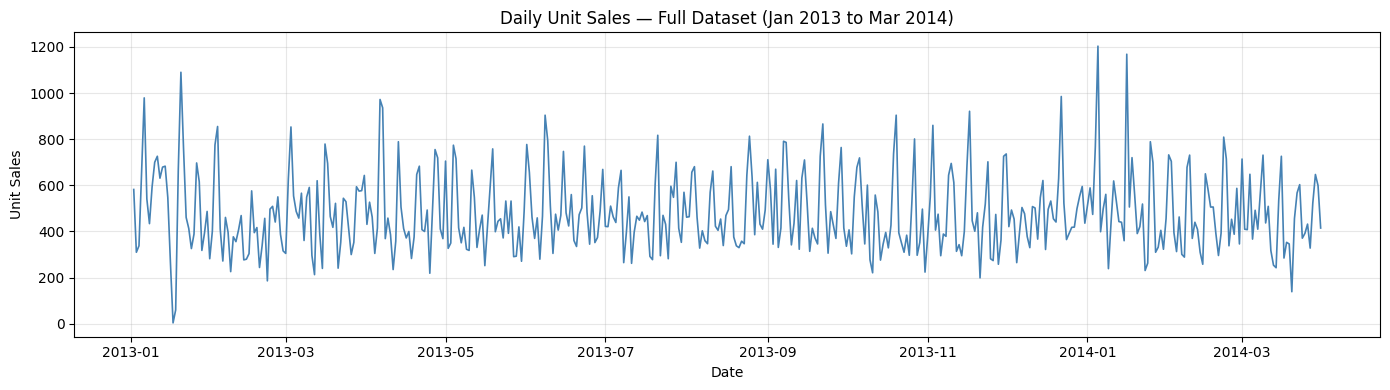

In [ ]:
# Plot unit_sales over time
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', linewidth=1.2)
plt.title('Daily Unit Sales — Full Dataset (Jan 2013 to Mar 2014)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# What to look for:
# - Is there an upward or downward trend?
# - Are there repeating weekly patterns?
# - Are there unusual spikes (likely holidays or weekends)?

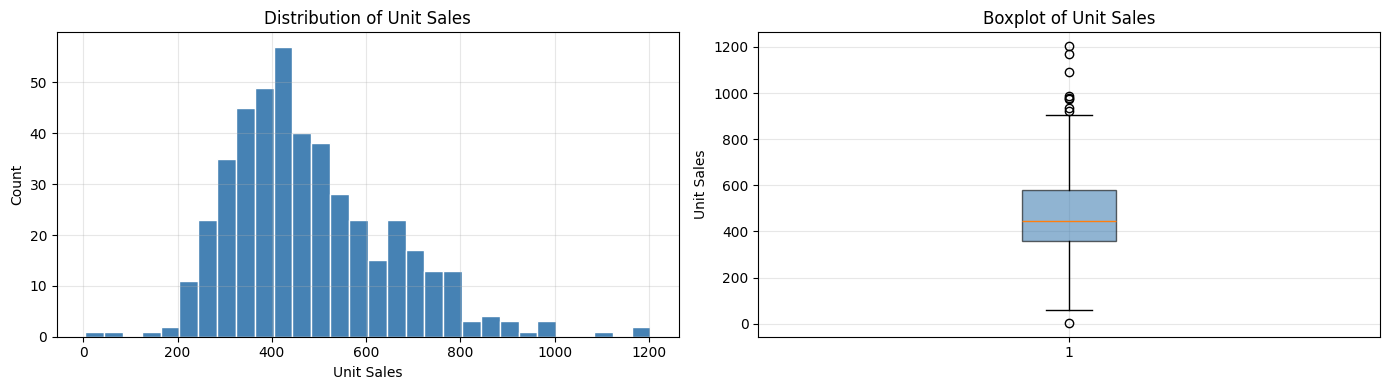

Unit Sales summary:
count     452.00
mean      480.09
std       170.84
min         4.00
25%       358.00
50%       445.50
75%       578.25
max      1203.00
Name: unit_sales, dtype: float64


In [ ]:
# Plot the distribution of unit_sales
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['unit_sales'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Unit Sales')
axes[0].set_xlabel('Unit Sales')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Box plot to see spread and outliers
axes[1].boxplot(df['unit_sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot of Unit Sales')
axes[1].set_ylabel('Unit Sales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Unit Sales summary:")
print(df['unit_sales'].describe().round(2))

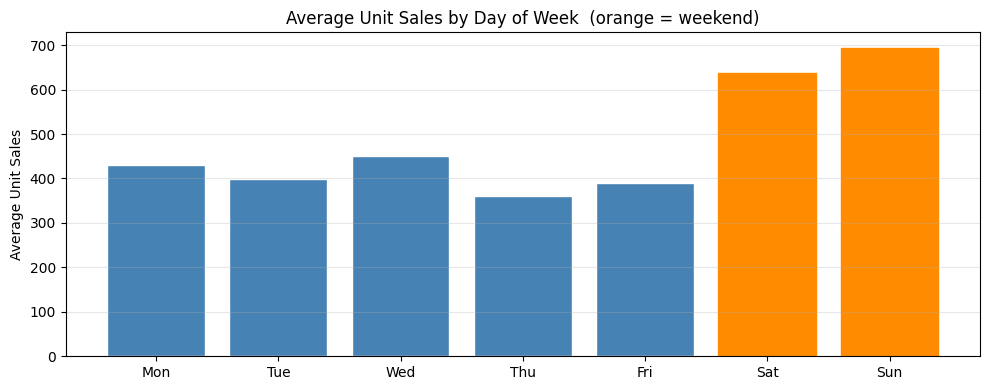

In [ ]:
# Plot average sales by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('dayofweek')['unit_sales'].mean()

plt.figure(figsize=(10, 4))
bars = plt.bar(day_names, avg_by_day.values, color='steelblue', edgecolor='white')

# Highlight weekends
for i in [5, 6]:
    bars[i].set_color('darkorange')

plt.title('Average Unit Sales by Day of Week  (orange = weekend)')
plt.ylabel('Average Unit Sales')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# This confirms that weekends drive significantly higher sales
# dayofweek is therefore one of the most important features

---
## Step 5 — Feature Importance

Before choosing which features to give each model, we measure how much each feature  
contributes to predicting unit_sales.

We use two approaches:

**1. Correlation** — measures the linear relationship between each feature and unit_sales.  
Simple and fast, but only captures straight-line relationships.

**2. Random Forest Feature Importance** — measures how much each feature reduces  
prediction error across many decision trees.  
More powerful — captures non-linear relationships too.

> Note: Feature importance tells us which features are informative.  
> But each model has its own rules about which types of features it can actually accept.  
> We will apply those rules in each model's section.

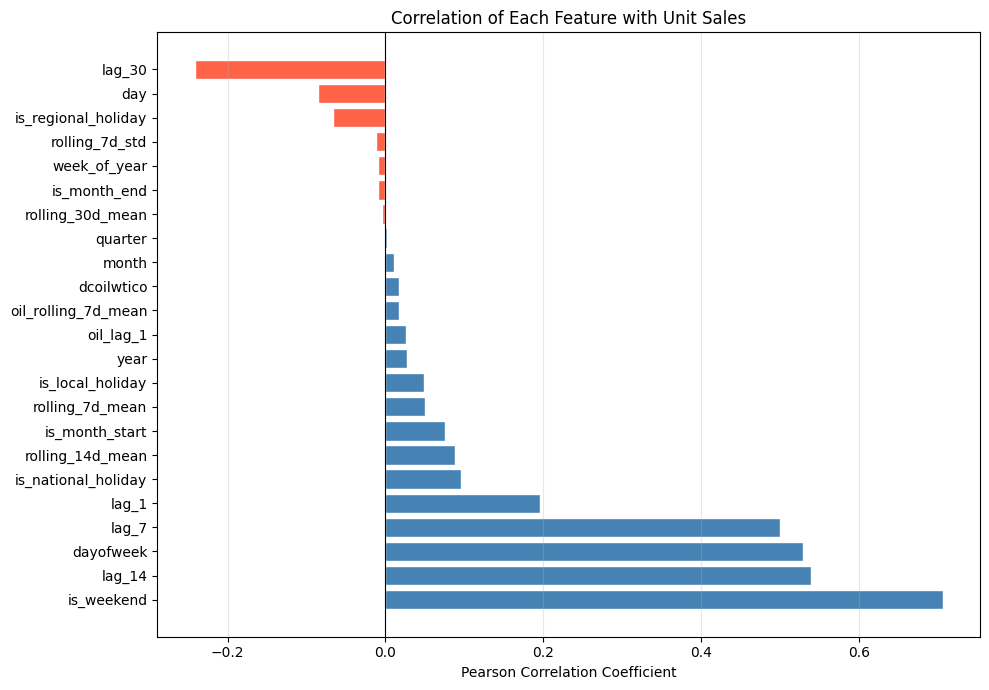

In [ ]:
# Correlation with unit_sales (Linear relationship)
# When this feature goes up, does unit_sales tend to go up or down in a straight-line pattern?

# Drop rows with NaN (from lag/rolling features) before calculating correlation
df_clean = df.dropna().reset_index(drop=True)

# The following code just choose the numeric columns as peason correlation is only for numerics
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('unit_sales')   # remove target from features list

correlations = df_clean[numeric_cols].corrwith(df_clean['unit_sales'])
correlations = correlations.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Each Feature with Unit Sales')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

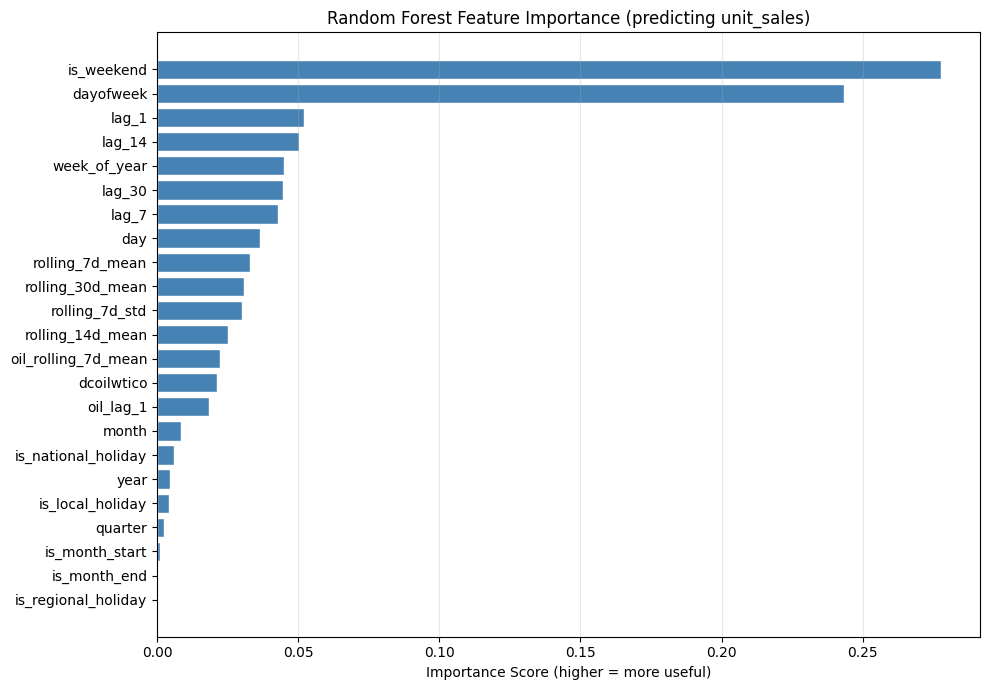

In [ ]:
# Random Forest Feature (Non-linear relationships)
# Which feature, if I split on it here, reduces my prediction error the most?

X = df_clean[numeric_cols]
y = df_clean['unit_sales']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

# Get importance scores
importance = pd.Series(rf.feature_importances_, index=numeric_cols)
importance = importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(importance.index, importance.values, color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importance (predicting unit_sales)')
plt.xlabel('Importance Score (higher = more useful)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: combine correlation and RF importance side by side

importance_df = pd.DataFrame({
    'Correlation with unit_sales': correlations.round(3),
    'RF Importance':               importance.sort_values(ascending=False).round(4)
})

print("Feature Importance Summary:")
print()
print(importance_df.sort_values('RF Importance', ascending=False).to_string())

Feature Importance Summary:

                     Correlation with unit_sales  RF Importance
is_weekend                                 0.706         0.2777
dayofweek                                  0.529         0.2434
lag_1                                      0.196         0.0521
lag_14                                     0.539         0.0501
week_of_year                              -0.009         0.0448
lag_30                                    -0.242         0.0444
lag_7                                      0.500         0.0428
day                                       -0.085         0.0366
rolling_7d_mean                            0.050         0.0329
rolling_30d_mean                          -0.005         0.0309
rolling_7d_std                            -0.012         0.0301
rolling_14d_mean                           0.088         0.0250
oil_rolling_7d_mean                        0.018         0.0223
dcoilwtico                                 0.018         0.0213
oil_lag_1  

---
## Step 6 — Train / Test Split

We split the data into training and test sets **by time** — never randomly.  
The model must always train on older data and be tested on newer data it has never seen.

We use the **last 60 days** as the test set.  
This gives us about 2 months of unseen data to evaluate each model on.

In [ ]:
# Split: last 90 days = test set, everything before = training set
# Me: there are more ways to split the data, but this is the most common for time series
# Me: In this project, we are asked to do it only for january till March

TEST_SIZE = 89

train = df.iloc[:-TEST_SIZE].copy()
test  = df.iloc[-TEST_SIZE:].copy()

# Drop NaN rows from training (caused by lag/rolling features at the start)
train_clean = train.dropna().reset_index(drop=True)

print("Training set:", len(train), "days (", len(train_clean), "after dropping NaN rows)")
print("  From:", train['date'].min().date(), "to", train['date'].max().date())
print()
print("Test set:", len(test), "days")
print("  From:", test['date'].min().date(), "to", test['date'].max().date())

Training set: 363 days ( 333 after dropping NaN rows)
  From: 2013-01-02 to 2013-12-31

Test set: 89 days
  From: 2014-01-02 to 2014-03-31


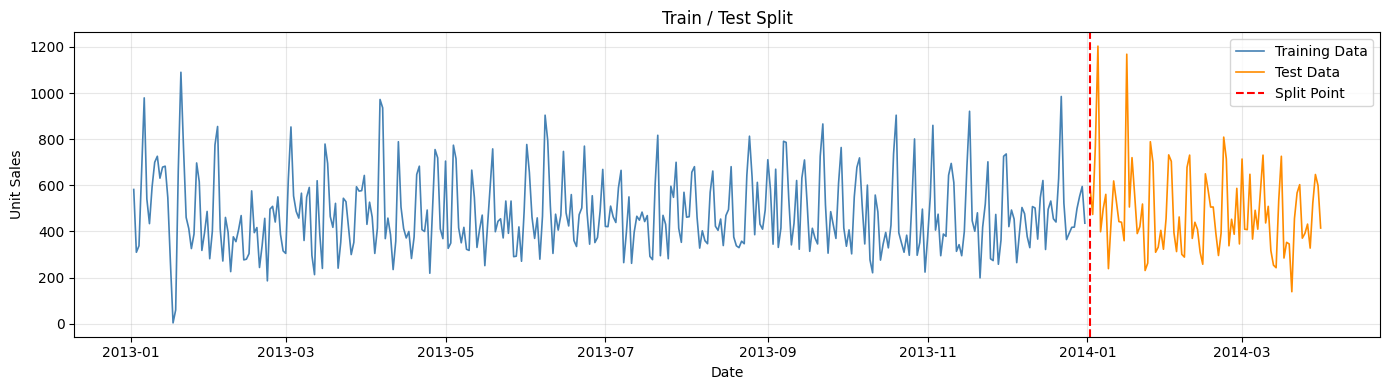

In [ ]:
# Visualise the split

plt.figure(figsize=(14, 4))
plt.plot(train['date'], train['unit_sales'], label='Training Data', color='steelblue', linewidth=1.2)
plt.plot(test['date'],  test['unit_sales'],  label='Test Data',     color='darkorange', linewidth=1.2)
plt.axvline(x=test['date'].min(), color='red', linestyle='--', linewidth=1.5, label='Split Point')
plt.title('Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Model 1 — ARIMA / SARIMAX

### What is ARIMA?

ARIMA stands for **AutoRegressive Integrated Moving Average**.  
It forecasts a series using three mechanisms:
.

Me: Remeber in this table, Sarimax is considered a type of Arima.


| Component | Parameter | What it does |
|---|---|---|
| **AR** — AutoRegressive | p | Uses past values of the series to predict the future |
| **I** — Integrated | d | Differences the series to remove trend and make it stationary |
| **MA** — Moving Average | q | Uses past forecast errors to correct predictions |

**SARIMAX** extends ARIMA in two directions:
- **S** adds seasonal versions of p, d, q at a given period (e.g. every 7 days)
- **X** allows external regressors — extra input columns like oil price or holiday flags

### Which features does ARIMA/SARIMAX use?

| Feature type | Can ARIMA use it? | How |
|---|---|---|
| The target series (unit_sales) | Yes — required | Endogenous variable |
| Oil price, holiday flags | Yes | As exogenous regressors (the X in SARIMAX) |
| Lag features (lag_1, lag_7...) | No | ARIMA computes its own internal lags via the p parameter |
| Rolling averages | No | ARIMA handles smoothing internally |
| Calendar features (month, day) | Indirectly | Only if added as exogenous regressors |

> **Key rule:** Do not pass lag or rolling features as regressors to ARIMA.  
> These overlap with what ARIMA already does internally and can cause errors.

### Step 7 — Check Stationarity

In [ ]:
# ARIMA requires the series to be stationary (no trend, stable variance)
# We use the Augmented Dickey-Fuller (ADF) test to check this

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    print("ADF Test —", name)
    print("  p-value:", round(p_value, 4))
    if p_value <= 0.05:
        print("  Result: Stationary — ready for ARIMA")
    else:
        print("  Result: NOT stationary — differencing needed (set d > 0)")
    print()

# Test the raw unit_sales series
check_stationarity(train['unit_sales'], 'unit_sales (original)')

ADF Test — unit_sales (original)
  p-value: 0.0007
  Result: Stationary — ready for ARIMA



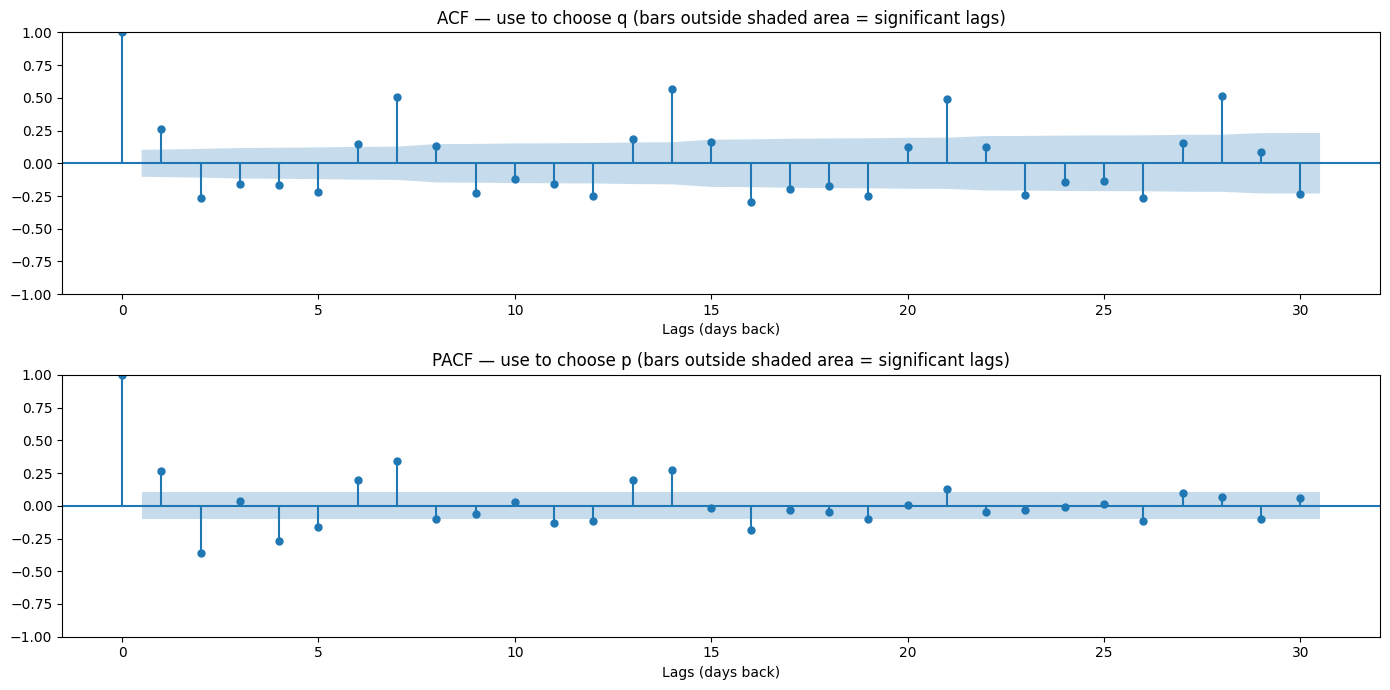

How to read these plots:
  PACF: count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is p
  ACF:  count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is q
  A spike at lag 7 in either plot → weekly seasonality → consider seasonal ARIMA (S parameter)


In [ ]:
# Plot ACF and PACF to choose p and q parameters
# ACF  → helps choose q (Moving Average order)
# PACF → helps choose p (AutoRegressive order)

series = train['unit_sales'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title('ACF — use to choose q (bars outside shaded area = significant lags)')
axes[0].set_xlabel('Lags (days back)')

plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title('PACF — use to choose p (bars outside shaded area = significant lags)')
axes[1].set_xlabel('Lags (days back)')

plt.tight_layout()
plt.show()

print("How to read these plots:")
print("  PACF: count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is p")
print("  ACF:  count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is q")
print("  A spike at lag 7 in either plot → weekly seasonality → consider seasonal ARIMA (S parameter)")

# Me: The above line is exacrly correct (we have weekly seasonality), and we must use SARIMA OR SARIMAX

### Step 8 — Prepare Exogenous Features for SARIMAX

In [ ]:
# SARIMAX accepts external columns as 'exogenous regressors'
# These are features that are NOT the target series but help explain its variation

# We select: oil price, holiday flags, and weekend flag
# These are genuinely external — the model cannot derive them from the sales series itself

# Me= he has intentionally left not very good features out to show..b but I must put the best ones myself.


exog_cols = ['dcoilwtico', 'is_national_holiday', 'is_regional_holiday',
             'is_local_holiday', 'is_weekend']

# Training exogenous features (must align row-for-row with the training series)
exog_train = train[exog_cols].copy()
exog_test  = test[exog_cols].copy()

print("Exogenous features selected for SARIMAX:")
for col in exog_cols:
    print(" ", col)
print()
print("Training exog shape:", exog_train.shape)
print("Test exog shape:    ", exog_test.shape)
print()
print("First 5 rows of exog features:")
print(exog_train.head())

Exogenous features selected for SARIMAX:
  dcoilwtico
  is_national_holiday
  is_regional_holiday
  is_local_holiday
  is_weekend

Training exog shape: (363, 5)
Test exog shape:     (89, 5)

First 5 rows of exog features:
   dcoilwtico  is_national_holiday  is_regional_holiday  is_local_holiday  \
0   93.140000                    0                    0                 0   
1   92.970000                    0                    0                 0   
2   93.120000                    0                    0                 0   
3   93.146667                    1                    0                 0   
4   93.173333                    0                    0                 0   

   is_weekend  
0           0  
1           0  
2           0  
3           1  
4           1  


### Step 9 — Factors That Influence ARIMA Performance

Before fitting, it helps to understand what can make ARIMA better or worse:

| Factor | Effect |
|---|---|
| **p (AR order)** | Higher p = more past values used. Too high → overfitting |
| **d (differencing)** | Must make the series stationary. Usually 0 or 1 |
| **q (MA order)** | Higher q = uses more past errors. Too high → overfitting |
| **Seasonal order (P,D,Q,s)** | Captures repeating cycles (e.g. every 7 days for weekly data) |
| **Exogenous regressors** | External features (oil, holidays) that explain variation ARIMA cannot see on its own |
| **Data length** | ARIMA needs sufficient history to estimate parameters reliably |
| **Stationarity** | Non-stationary data leads to unreliable parameter estimates |

### Step 10 — Fit the SARIMAX Model

In [ ]:
# We fit SARIMAX with:
# order=(1,0,1)         → AR=1, no differencing (series is stationary), MA=1
# seasonal_order=(1,0,0,7) → weekly seasonal AR, no seasonal differencing, period=7 days

print("Fitting SARIMAX model...")
print("  order=(1, 0, 1)")
print("  seasonal_order=(1, 0, 0, 7)  — weekly seasonality")
print("  exog: oil price + holiday flags + weekend flag")
print()

arima_model = SARIMAX(
    train['unit_sales'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    exog=exog_train
)

arima_fit = arima_model.fit(disp=False)

print("Model fitted successfully!")
print()
print(arima_fit.summary())

Fitting SARIMAX model...
  order=(1, 0, 1)
  seasonal_order=(1, 0, 0, 7)  — weekly seasonality
  exog: oil price + holiday flags + weekend flag

Model fitted successfully!

                                     SARIMAX Results                                      
Dep. Variable:                         unit_sales   No. Observations:                  363
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 7)   Log Likelihood               -2245.634
Date:                            Tue, 28 Apr 2026   AIC                           4509.269
Time:                                    09:11:46   BIC                           4544.318
Sample:                                         0   HQIC                          4523.201
                                            - 363                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------

### Step 11 — ARIMA Forecast and Evaluation

In [ ]:
# Generate forecasts for the test period

arima_preds = arima_fit.forecast(steps=len(test), exog=exog_test)

# Clip negative predictions (sales cannot be negative)
arima_preds = arima_preds.clip(lower=0)

print("Forecast generated for", len(test), "days.")
print()
print("First 5 predictions:")
print(arima_preds.head().round(2))

Forecast generated for 89 days.

First 5 predictions:
363    367.01
364    383.74
365    635.05
366    615.59
367    372.84
Name: predicted_mean, dtype: float64


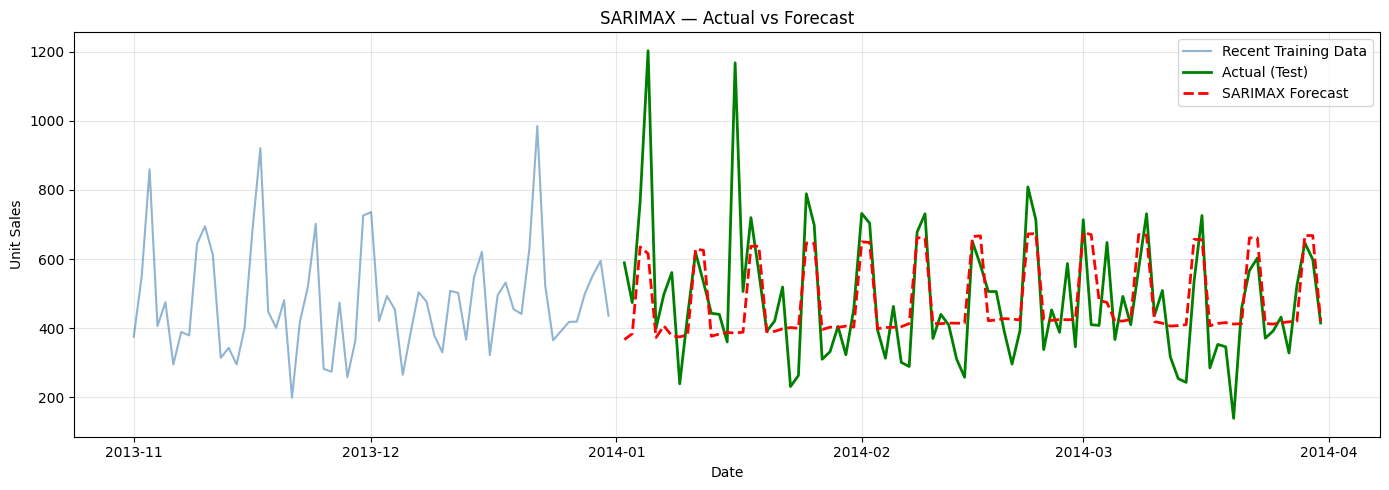

In [ ]:
# Plot actual vs predicted
# Me: From the train data, it will choose only the last 60 days to show the recent trend. 

plt.figure(figsize=(14, 5))
plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=1.5, alpha=0.6)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='green', linewidth=2)
plt.plot(test['date'], arima_preds.values,
         label='SARIMAX Forecast', color='red', linewidth=2, linestyle='--')
plt.title('SARIMAX — Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate ARIMA performance using multiple metrics

actual = test['unit_sales'].values

arima_mae  = mean_absolute_error(actual, arima_preds)
arima_rmse = mean_squared_error(actual, arima_preds) ** 0.5
arima_mape = mean_absolute_percentage_error(actual, arima_preds) * 100
arima_r2   = r2_score(actual, arima_preds)

print("SARIMAX Model — Evaluation Metrics:")
print()
print("  MAE  (Mean Absolute Error)         :", round(arima_mae, 2),  "units")
print("    → Average absolute difference between forecast and actual")
print()
print("  RMSE (Root Mean Squared Error)     :", round(arima_rmse, 2), "units")
print("    → Like MAE but penalises large errors more heavily")
print()
print("  MAPE (Mean Absolute % Error)       :", round(arima_mape, 2), "%")
print("    → Average percentage error — useful for comparing across datasets")
print()
print("  R²   (Coefficient of Determination):", round(arima_r2, 4))
print("    → How much variance the model explains (1.0 = perfect, 0 = no better than mean)")

SARIMAX Model — Evaluation Metrics:

  MAE  (Mean Absolute Error)         : 94.53 units
    → Average absolute difference between forecast and actual

  RMSE (Root Mean Squared Error)     : 142.02 units
    → Like MAE but penalises large errors more heavily

  MAPE (Mean Absolute % Error)       : 22.02 %
    → Average percentage error — useful for comparing across datasets

  R²   (Coefficient of Determination): 0.407
    → How much variance the model explains (1.0 = perfect, 0 = no better than mean)


---
## Model 2 — Holt-Winters (Triple Exponential Smoothing)

### What is Holt-Winters?

Holt-Winters models a time series as three separate components that are each updated at every time step:

| Component | Parameter | What it tracks |
|---|---|---|
| **Level** | Alpha (α) | The current average value of the series |
| **Trend** | Beta (β) | How fast the average is changing (direction) |
| **Seasonal** | Gamma (γ) | The repeating pattern at each period |

**Additive vs Multiplicative seasonality:**
- **Additive** — the seasonal swing is a fixed size regardless of the level
- **Multiplicative** — the seasonal swing grows as the level grows

For our data, weekends consistently drive higher sales regardless of the overall level,  
which suggests additive seasonality. We will test both and compare.

### Which features does Holt-Winters use?

| Feature type | Can Holt-Winters use it? |
|---|---|
| The target series (unit_sales) | Yes — required |
| Oil price, holiday flags, lag features, calendar features | No — Holt-Winters only uses the target series |

### Step 12 — Factors That Influence Holt-Winters Performance

| Factor | Effect |
|---|---|
| **Alpha (α)** | Controls level smoothing. High α = reacts fast to recent values |
| **Beta (β)** | Controls trend smoothing. High β = trend updates quickly |
| **Gamma (γ)** | Controls seasonal smoothing. High γ = seasonal pattern updates quickly |
| **Seasonal period** | Must match the real cycle in the data (7 for weekly, 12 for monthly) |
| **Additive vs Multiplicative** | Multiplicative is better when seasonal swings grow with the level |
| **Damped trend** | Adds a dampening factor so the trend gradually flattens — useful for long forecasts |
| **Optimized=True** | Lets the model choose α, β, γ automatically by minimising training error |

### Step 13 — Fit Holt-Winters

In [ ]:
# Holt-Winters requires a clean series with no NaN values and the seasonal_periods must match the actual cycle in the data

# Our data is daily with a strong weekly cycle → seasonal_periods=7

print("Fitting Holt-Winters Additive model...")
hw_add = ExponentialSmoothing(
    train['unit_sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
)
hw_add_fit = hw_add.fit(
    smoothing_level=0.3,
    smoothing_trend=0.01,
    smoothing_seasonal=0.3,
    optimized=False
)

print("Fitting Holt-Winters Multiplicative model...")
hw_mul = ExponentialSmoothing(
    train['unit_sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=7
)
hw_mul_fit = hw_mul.fit(
    smoothing_level=0.3,
    smoothing_trend=0.01,
    smoothing_seasonal=0.3,
    optimized=False
)

print()
print("Both models fitted successfully!")
print()
print("Additive model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_add_fit.params['smoothing_level'], 4))
print("  Beta  (trend)   :", round(hw_add_fit.params['smoothing_trend'], 4))
print("  Gamma (seasonal):", round(hw_add_fit.params['smoothing_seasonal'], 4))
print()
print("Multiplicative model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_mul_fit.params['smoothing_level'], 4))
print("  Beta  (trend)   :", round(hw_mul_fit.params['smoothing_trend'], 4))
print("  Gamma (seasonal):", round(hw_mul_fit.params['smoothing_seasonal'], 4))

Fitting Holt-Winters Additive model...
Fitting Holt-Winters Multiplicative model...

Both models fitted successfully!

Additive model parameters chosen automatically:
  Alpha (level)   : 0.3
  Beta  (trend)   : 0.01
  Gamma (seasonal): 0.3

Multiplicative model parameters chosen automatically:
  Alpha (level)   : 0.3
  Beta  (trend)   : 0.01
  Gamma (seasonal): 0.3


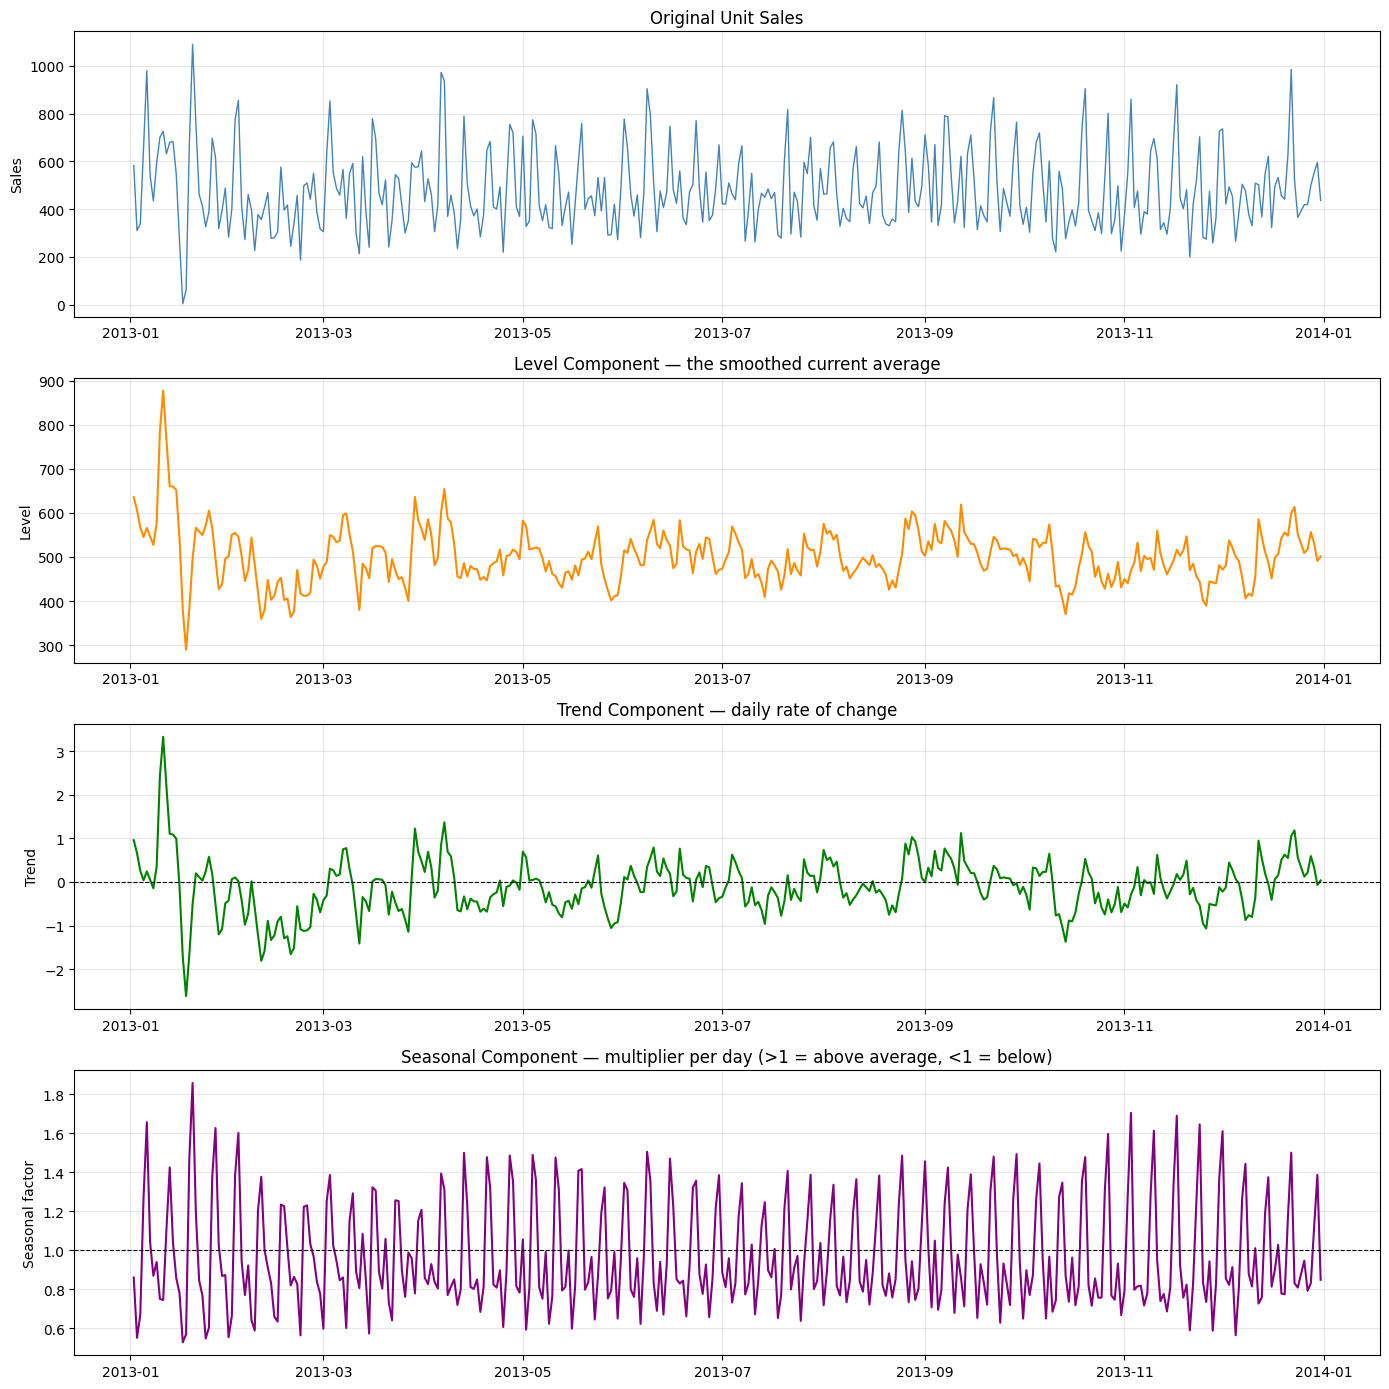

In [ ]:
# Visualise the three internal components learned by the multiplicative model
#Me: Graph is wrong........ ???

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

axes[0].plot(train['date'], train['unit_sales'], color='steelblue', linewidth=1)
axes[0].set_title('Original Unit Sales')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train['date'], hw_mul_fit.level, color='darkorange', linewidth=1.5)
axes[1].set_title('Level Component — the smoothed current average')
axes[1].set_ylabel('Level')
axes[1].grid(True, alpha=0.3)

axes[2].plot(train['date'], hw_mul_fit.trend, color='green', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Trend Component — daily rate of change')
axes[2].set_ylabel('Trend')
axes[2].grid(True, alpha=0.3)

axes[3].plot(train['date'], hw_mul_fit.season, color='purple', linewidth=1.5)
axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[3].set_title('Seasonal Component — multiplier per day (>1 = above average, <1 = below)')
axes[3].set_ylabel('Seasonal factor')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Print the seasonal factor for each day of the week

# Me: In the second line, hw_mul_fit.season is the seasonal component learned by the model 
# during training. Since the model uses seasonal_periods=7 (weekly cycle), this component 
# contains 7 values representing the seasonal multiplier for each day of the week.


day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
seasonal_factors = hw_mul_fit.season[-7:].values

print("Seasonal factors by day of week (multiplicative model):")
print("  > 1.0 = that day tends to be ABOVE the weekly average")
print("  < 1.0 = that day tends to be BELOW the weekly average")
print()

for day, factor in zip(day_names, seasonal_factors):
    bar = '#' * int(abs(factor) * 15)
    print(f"  {day}: {factor:.3f}  {bar}")

Seasonal factors by day of week (multiplicative model):
  > 1.0 = that day tends to be ABOVE the weekly average
  < 1.0 = that day tends to be BELOW the weekly average

  Mon: 0.808  ############
  Tue: 0.946  ##############
  Wed: 0.791  ###########
  Thu: 0.830  ############
  Fri: 1.118  ################
  Sat: 1.386  ####################
  Sun: 0.847  ############


### Step 14 — Holt-Winters Forecast and Evaluation

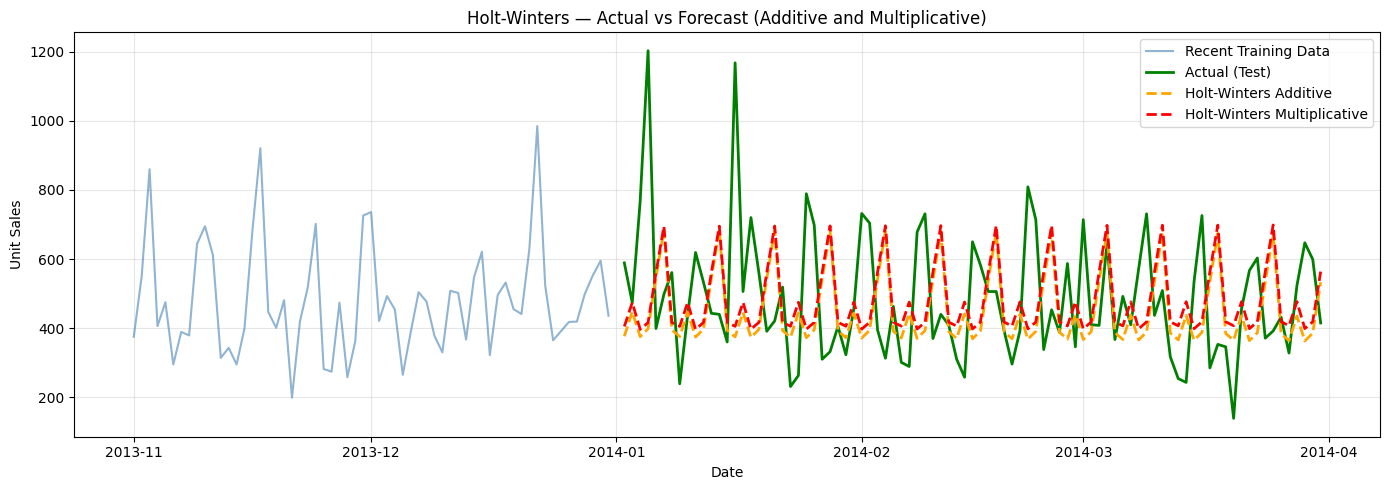

In [ ]:
# Generate forecasts from both additive and multiplicative models

hw_add_preds = hw_add_fit.forecast(steps=len(test))
hw_mul_preds = hw_mul_fit.forecast(steps=len(test))

# Clip to zero (no negative sales)
hw_add_preds = hw_add_preds.clip(lower=0)
hw_mul_preds = hw_mul_preds.clip(lower=0)

# Plot both
plt.figure(figsize=(14, 5))
plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=1.5, alpha=0.6)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='green', linewidth=2)
plt.plot(test['date'], hw_add_preds.values,
         label='Holt-Winters Additive', color='orange', linewidth=2, linestyle='--')
plt.plot(test['date'], hw_mul_preds.values,
         label='Holt-Winters Multiplicative', color='red', linewidth=2, linestyle='--')
plt.title('Holt-Winters — Actual vs Forecast (Additive and Multiplicative)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate both Holt-Winters variants

def score_model(name, actual, predictions):
    mae  = mean_absolute_error(actual, predictions)
    rmse = mean_squared_error(actual, predictions) ** 0.5
    mape = mean_absolute_percentage_error(actual, predictions) * 100
    r2   = r2_score(actual, predictions)
    print(f"{name}:")
    print(f"  MAE : {mae:.2f}   RMSE: {rmse:.2f}   MAPE: {mape:.2f}%   R²: {r2:.4f}")
    print()
    return mae, rmse, mape, r2

actual = test['unit_sales'].values

print("Holt-Winters Evaluation Results:")
print()
hw_add_scores = score_model('Additive',       actual, hw_add_preds.values)
hw_mul_scores = score_model('Multiplicative', actual, hw_mul_preds.values)

# Keep the better variant for the final comparison
if hw_mul_scores[0] < hw_add_scores[0]:
    hw_best_preds  = hw_mul_preds.values
    hw_best_label  = 'Holt-Winters Multiplicative'
    hw_best_scores = hw_mul_scores
    print("Multiplicative model wins — using it for final comparison")
else:
    hw_best_preds  = hw_add_preds.values
    hw_best_label  = 'Holt-Winters Additive'
    hw_best_scores = hw_add_scores
    print("Additive model wins — using it for final comparison")

Holt-Winters Evaluation Results:

Additive:
  MAE : 184.86   RMSE: 235.83   MAPE: 38.45%   R²: -0.6350

Multiplicative:
  MAE : 187.67   RMSE: 232.69   MAPE: 40.98%   R²: -0.5918

Additive model wins — using it for final comparison


---
## Model 3 — Prophet

### What is Prophet?

Prophet is a forecasting tool developed by Facebook (Meta).  
It models a time series as the sum of three components:

**Forecast = Trend + Seasonality + Holidays**

It uses Bayesian statistical fitting (not machine learning in the traditional sense),  
and Fourier series to represent seasonal patterns.

### Which features does Prophet use?

| Feature type | Can Prophet use it? | How |
|---|---|---|
| Target series (unit_sales) | Yes — required | The `y` column |
| Holiday flags | Yes — built-in support | `add_country_holidays()` or manual holiday dataframe |
| Oil price and other external signals | Yes | As additional regressors via `add_regressor()` |
| Lag features, rolling averages | No — avoid | These leak future information and cause overfitting |
| Calendar features (month, dayofweek) | No — not needed | Prophet extracts these automatically from the date |

### How Prophet differs from ARIMA and Holt-Winters

| | ARIMA | Holt-Winters | Prophet |
|---|---|---|---|
| External features | Via exog | Not supported | Via `add_regressor()` |
| Holiday handling | Manual | Not supported | Built-in |
| Multiple seasonality | Complex | One period only | Easy to add |
| Confidence intervals | Extra steps | Not built-in | Automatic |
| Missing dates | Needs fixing | Needs fixing | Handles automatically |

### Step 15 — Factors That Influence Prophet Performance

| Factor | Effect |
|---|---|
| **changepoint_prior_scale** | How flexible the trend is (default=0.05). Higher = more trend changes detected |
| **seasonality_prior_scale** | How much weight to give seasonality (default=10). Higher = stronger seasonal effect |
| **seasonality_mode** | Additive vs multiplicative — same choice as Holt-Winters |
| **Fourier order** | Higher order = more complex seasonal pattern captured (risk of overfitting) |
| **Additional regressors** | External signals like oil price can improve accuracy if they genuinely drive sales |
| **Holiday dataframe** | Passing known holiday dates helps the model treat them separately from normal days |
| **forecast horizon** | Prophet's uncertainty grows for longer horizons — confidence intervals widen |

### Step 16 — Prepare Data for Prophet

In [ ]:
# Prophet requires exactly two columns: 'ds' (date) and 'y' (target)

prophet_train = train[['date', 'unit_sales']].copy()
prophet_train = prophet_train.rename(columns={'date': 'ds', 'unit_sales': 'y'})

prophet_test = test[['date', 'unit_sales']].copy()
prophet_test = prophet_test.rename(columns={'date': 'ds', 'unit_sales': 'y'})

print("Prophet training data prepared:")
print(prophet_train.head())
print()
print("Shape:", prophet_train.shape)

Prophet training data prepared:
          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
3 2013-01-05  654.0
4 2013-01-06  979.0

Shape: (363, 2)


In [ ]:
# Build a holiday dataframe for Prophet
# Prophet accepts a special table of holiday dates with names

national_holiday_dates = df[df['is_national_holiday'] == 1]['date'].tolist()
regional_holiday_dates = df[df['is_regional_holiday'] == 1]['date'].tolist()
local_holiday_dates    = df[df['is_local_holiday'] == 1]['date'].tolist()

holidays_prophet = pd.DataFrame({
    'holiday': (
        ['national_holiday'] * len(national_holiday_dates) +
        ['regional_holiday'] * len(regional_holiday_dates) +
        ['local_holiday']    * len(local_holiday_dates)
    ),
    'ds': national_holiday_dates + regional_holiday_dates + local_holiday_dates
})

print("Holiday dataframe for Prophet:")
print()
print(holidays_prophet.head(10))
print()
print("Total holiday dates passed to Prophet:", len(holidays_prophet))

Holiday dataframe for Prophet:

            holiday         ds
0  national_holiday 2013-01-05
1  national_holiday 2013-01-12
2  national_holiday 2013-02-11
3  national_holiday 2013-02-12
4  national_holiday 2013-04-29
5  national_holiday 2013-05-01
6  national_holiday 2013-05-11
7  national_holiday 2013-05-12
8  national_holiday 2013-05-24
9  national_holiday 2013-08-10

Total holiday dates passed to Prophet: 50


### Step 17 — Fit Prophet (Basic and Advanced)

In [ ]:
# Basic Prophet — uses default settings with weekly and yearly seasonality
# We also pass the holiday dataframe

print("Fitting Basic Prophet model...")

model_prophet_basic = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,     # weekly cycle (Mon–Sun patterns)
    yearly_seasonality=False,    # dataset is only 15 months — too short for yearly
    seasonality_mode='additive',
    holidays=holidays_prophet
)

model_prophet_basic.fit(prophet_train)

print("Basic Prophet fitted successfully!")

Fitting Basic Prophet model...


09:11:47 - cmdstanpy - INFO - Chain [1] start processing
09:11:47 - cmdstanpy - INFO - Chain [1] done processing


Basic Prophet fitted successfully!


In [ ]:
# Advanced Prophet — adds oil price as an external regressor
# and uses a higher Fourier order for the weekly seasonality

print("Fitting Advanced Prophet model (with oil price regressor)...")

model_prophet_adv = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,    # we will add custom weekly seasonality below
    yearly_seasonality=False,
    seasonality_mode='additive',
    holidays=holidays_prophet,
    changepoint_prior_scale=0.1  # slightly more flexible trend than default (0.05)
)

# Custom weekly seasonality with higher Fourier order
model_prophet_adv.add_seasonality(
    name='weekly_custom',
    period=7,
    fourier_order=5    # default is 3 — more terms = more complex weekly pattern
)

# Add oil price as an external regressor
# Prophet will learn how much oil price movements affect sales
model_prophet_adv.add_regressor('dcoilwtico')

# Add training data WITH the oil regressor column included
prophet_train_adv = prophet_train.copy()
prophet_train_adv['dcoilwtico'] = train['dcoilwtico'].values

model_prophet_adv.fit(prophet_train_adv)

print("Advanced Prophet fitted successfully!")

Fitting Advanced Prophet model (with oil price regressor)...


09:11:47 - cmdstanpy - INFO - Chain [1] start processing
09:11:47 - cmdstanpy - INFO - Chain [1] done processing


Advanced Prophet fitted successfully!


### Step 18 — Prophet Forecast and Evaluation

In [ ]:
# Create future dataframe for basic model (test period only)
# Me: For this code, first take a look at the related word file


future_basic = model_prophet_basic.make_future_dataframe(
    periods=len(test), freq='D'
)
forecast_basic = model_prophet_basic.predict(future_basic)

# Extract only the test period predictions
prophet_basic_preds = forecast_basic.tail(len(test))['yhat'].values
prophet_basic_preds = prophet_basic_preds.clip(0)

print("Basic Prophet forecasts generated.")

# .
# .

# Create future dataframe for advanced model — must include oil price column
future_adv = model_prophet_adv.make_future_dataframe(
    periods=len(test), freq='D'
)

# Attach oil prices to future dates (use test oil prices for forecast period)
oil_full = pd.concat([train['dcoilwtico'], test['dcoilwtico']], ignore_index=True)
future_adv['dcoilwtico'] = oil_full.values

forecast_adv = model_prophet_adv.predict(future_adv)

prophet_adv_preds = forecast_adv.tail(len(test))['yhat'].values
prophet_adv_preds = prophet_adv_preds.clip(0)

print("Advanced Prophet forecasts generated.")

Basic Prophet forecasts generated.
Advanced Prophet forecasts generated.


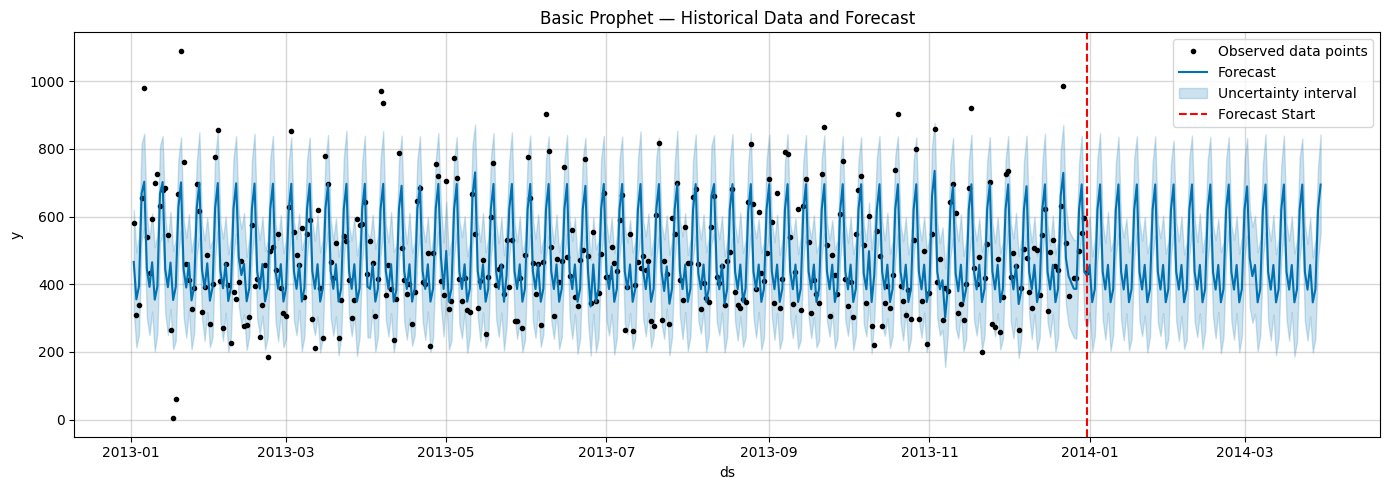

In [ ]:
# Plot Prophet's built-in forecast chart (basic model)
fig = model_prophet_basic.plot(forecast_basic, figsize=(14, 5))
plt.title('Basic Prophet — Historical Data and Forecast')
plt.axvline(x=prophet_train['ds'].max(), color='red', linestyle='--',
            linewidth=1.5, label='Forecast Start')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Prophet Evaluation Results:

Prophet Basic:
  MAE : 165.23   RMSE: 213.82   MAPE: 37.43%   R²: -0.3441

Prophet Advanced:
  MAE : 165.40   RMSE: 214.26   MAPE: 37.30%   R²: -0.3496



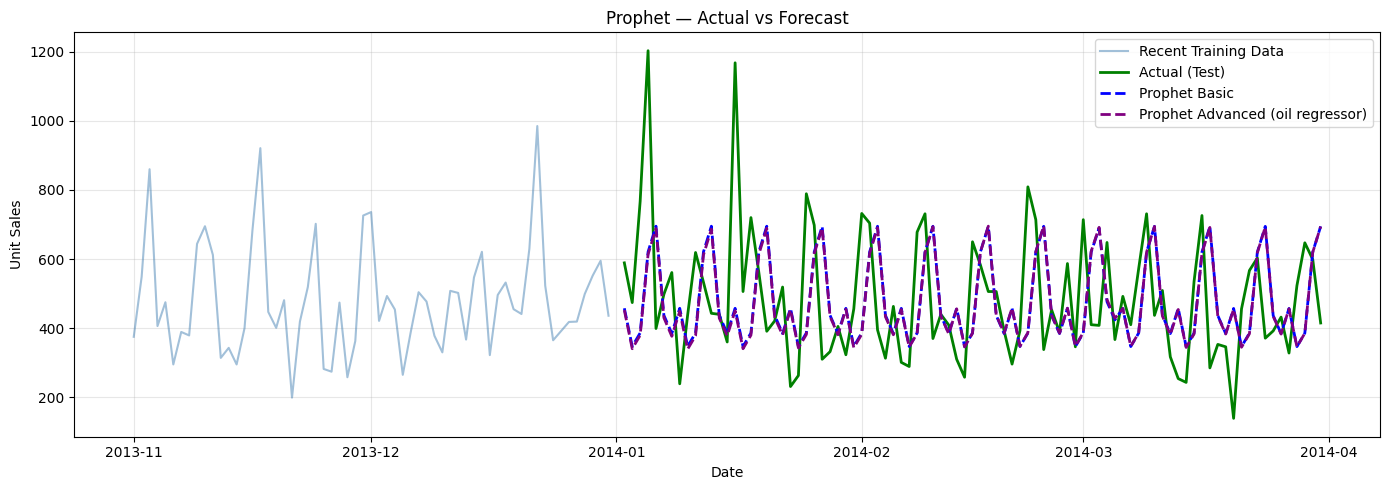

In [ ]:
# Evaluate both Prophet models

print("Prophet Evaluation Results:")
print()
prophet_basic_scores = score_model('Prophet Basic',    actual, prophet_basic_preds)
prophet_adv_scores   = score_model('Prophet Advanced', actual, prophet_adv_preds)

# Plot actual vs both Prophet forecasts
plt.figure(figsize=(14, 5))
plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=1.5, alpha=0.5)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='green', linewidth=2)
plt.plot(test['date'], prophet_basic_preds,
         label='Prophet Basic', color='blue', linewidth=2, linestyle='--')
plt.plot(test['date'], prophet_adv_preds,
         label='Prophet Advanced (oil regressor)', color='purple', linewidth=2, linestyle='--')
plt.title('Prophet — Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Me: As can be seen, oil price made no differende and adv ance and basic are almost the same.


---
## Step 19 — Model Performance Comparison

Now we compare all models on the same 60-day test set using the same metrics.

### Evaluation metrics explained

| Metric | Formula | What it tells you |
|---|---|---|
| **MAE** — Mean Absolute Error | Average of absolute errors | Average error in the same units as sales. Easy to interpret |
| **RMSE** — Root Mean Squared Error | √(average of squared errors) | Like MAE but penalises large errors more. Sensitive to outliers |
| **MAPE** — Mean Absolute Percentage Error | Average of % errors | Error as a percentage — useful for comparing across different datasets |
| **R²** — Coefficient of Determination | 1 − (error variance / total variance) | How much of the variation the model explains. 1.0 = perfect |

**Which metric to prioritise?**
- Use **MAE** when all errors matter equally
- Use **RMSE** when large errors are especially costly
- Use **MAPE** when communicating results to non-technical stakeholders
- Use **R²** when comparing models — higher is better

In [ ]:
# Collect all model scores into one comparison table


# Me: All the values it the following dictionary are calculated in the previous code cells.

all_results = [
    {'Model': 'SARIMAX(1,0,1)(1,0,0,7) + exog',  'MAE': arima_mae,           'RMSE': arima_rmse,           'MAPE': arima_mape,           'R²': arima_r2},
    {'Model': hw_best_label,                        'MAE': hw_best_scores[0],   'RMSE': hw_best_scores[1],   'MAPE': hw_best_scores[2],   'R²': hw_best_scores[3]},
    {'Model': 'Prophet Basic',                      'MAE': prophet_basic_scores[0], 'RMSE': prophet_basic_scores[1], 'MAPE': prophet_basic_scores[2], 'R²': prophet_basic_scores[3]},
    {'Model': 'Prophet Advanced (oil regressor)',   'MAE': prophet_adv_scores[0],   'RMSE': prophet_adv_scores[1],   'MAPE': prophet_adv_scores[2],   'R²': prophet_adv_scores[3]},
]

# Me: As we know the keys in dictionaries are like column labels. As a result, the 
# following dataframe will be a table with 5 columns (Model, MAE, RMSE, MAPE, R²) and 
# 4 rows (one for each model).

results_df = pd.DataFrame(all_results)

# Me: The following code rounds the values in the MAE, RMSE, MAPE, and R² columns.
results_df['MAE']  = results_df['MAE'].round(2)
results_df['RMSE'] = results_df['RMSE'].round(2)
results_df['MAPE'] = results_df['MAPE'].round(2)
results_df['R²']   = results_df['R²'].round(4)

print("Performance Comparison — All Models on the Same 60-Day Test Set:")
print()
print()
print(results_df.to_string(index=False))
print()
print()
print("Best MAE :", results_df.loc[results_df['MAE'].idxmin(),  'Model'])
print("Best RMSE:", results_df.loc[results_df['RMSE'].idxmin(), 'Model'])
print("Best R²  :", results_df.loc[results_df['R²'].idxmax(),   'Model'])

Performance Comparison — All Models on the Same 60-Day Test Set:


                           Model    MAE   RMSE  MAPE      R²
  SARIMAX(1,0,1)(1,0,0,7) + exog  94.53 142.02 22.02  0.4070
           Holt-Winters Additive 184.86 235.83 38.45 -0.6350
                   Prophet Basic 165.23 213.82 37.43 -0.3441
Prophet Advanced (oil regressor) 165.40 214.26 37.30 -0.3496


Best MAE : SARIMAX(1,0,1)(1,0,0,7) + exog
Best RMSE: SARIMAX(1,0,1)(1,0,0,7) + exog
Best R²  : SARIMAX(1,0,1)(1,0,0,7) + exog


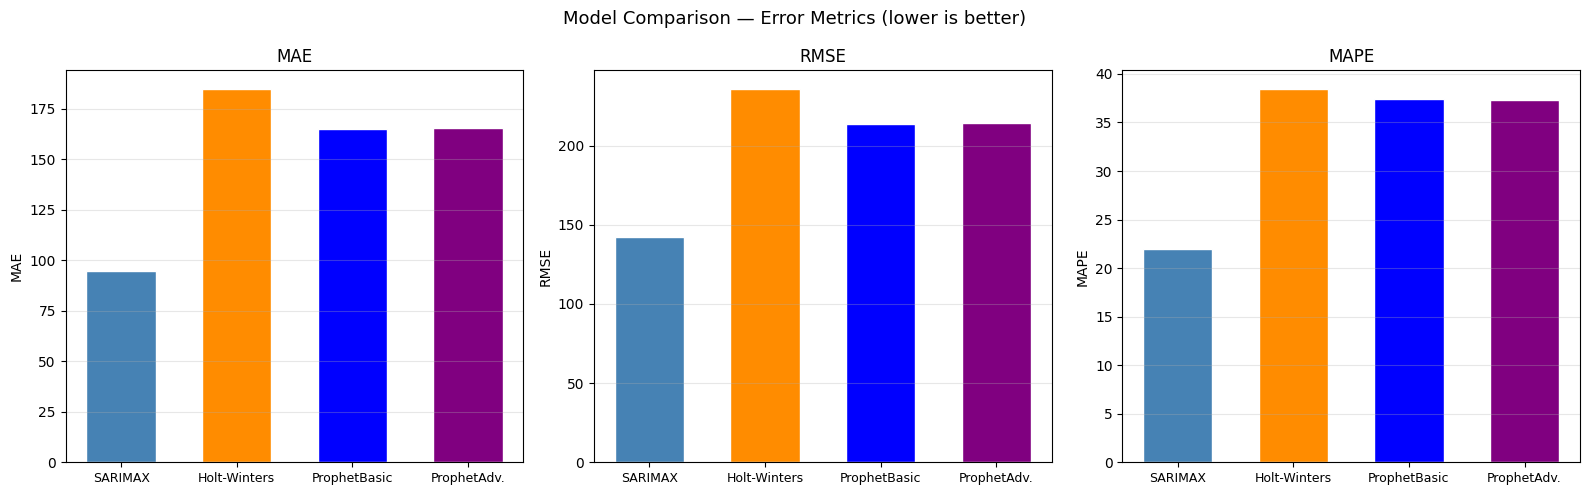

In [ ]:
# Visualise the comparison with a grouped bar chart

metrics = ['MAE', 'RMSE', 'MAPE']
x = range(len(results_df))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(x, results_df[metric], color=['steelblue', 'darkorange', 'blue', 'purple'],
                edgecolor='white', width=0.6)
    axes[i].set_title(metric)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(
        ['SARIMAX', 'Holt-Winters', 'ProphetBasic', 'ProphetAdv.'],
        fontsize=9
    )
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Error Metrics (lower is better)', fontsize=13)
plt.tight_layout()
plt.show()

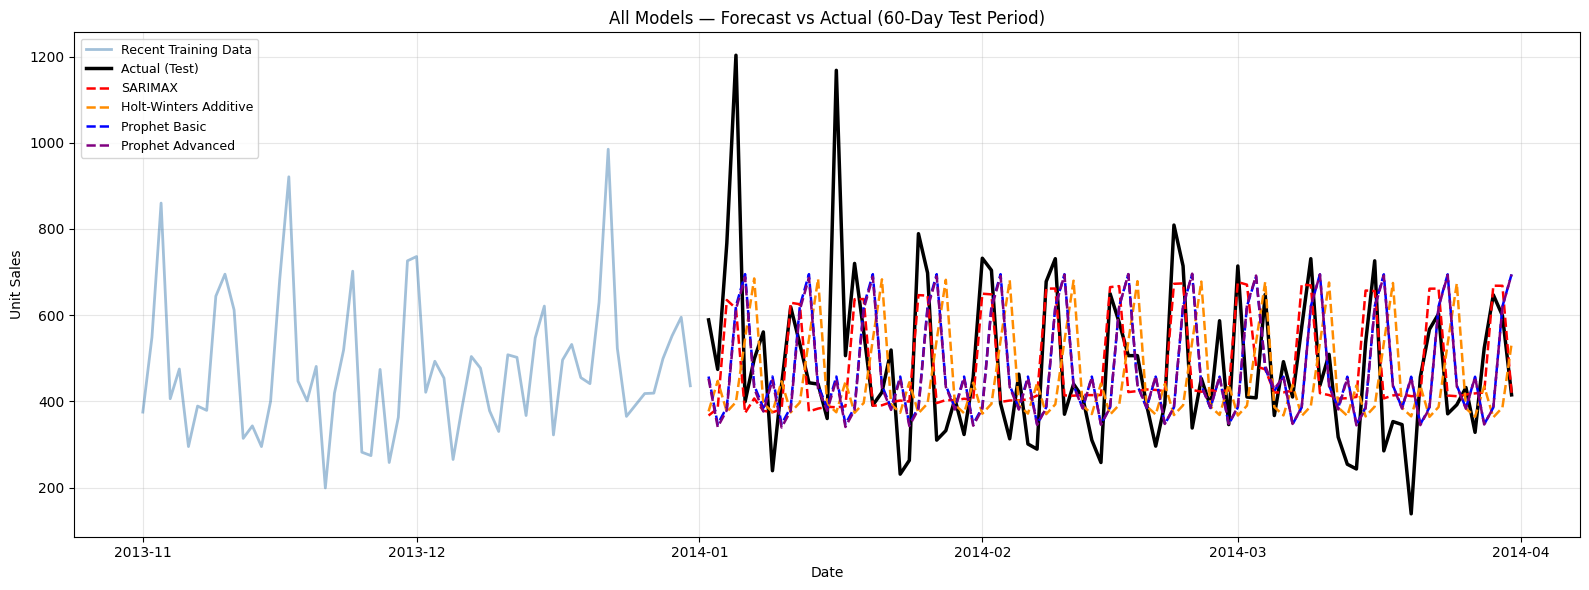

In [ ]:
# Plot all forecasts on one chart for visual comparison

plt.figure(figsize=(16, 6))

plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=2, alpha=0.5)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='black', linewidth=2.5)
plt.plot(test['date'], arima_preds.values,
         label='SARIMAX', color='red', linewidth=1.8, linestyle='--')
plt.plot(test['date'], hw_best_preds,
         label=hw_best_label, color='darkorange', linewidth=1.8, linestyle='--')
plt.plot(test['date'], prophet_basic_preds,
         label='Prophet Basic', color='blue', linewidth=1.8, linestyle='--')
plt.plot(test['date'], prophet_adv_preds,
         label='Prophet Advanced', color='purple', linewidth=1.8, linestyle='--')

plt.title('All Models — Forecast vs Actual (60-Day Test Period)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### What each model can and cannot use from the feature-engineered dataset

| Feature | SARIMAX | Holt-Winters | Prophet |
|---|---|---|---|
| `unit_sales` (target) | Required | Required | Required (as `y`) |
| `dcoilwtico` (oil price) | As exog regressor | Not supported | As `add_regressor()` |
| `is_national_holiday` | As exog regressor | Not supported | Via holiday dataframe |
| `is_weekend`, `dayofweek` | As exog regressor | Not supported | Learned automatically |
| `lag_1`, `lag_7`, etc. | Do not pass — ARIMA computes internally | Not supported | Do not pass — causes leakage |
| `rolling_7d_mean`, etc. | Do not pass | Not supported | Do not pass — causes leakage |

### When to choose each model

| Use case | Best model |
|---|---|
| Strong weekly pattern, external regressors available | SARIMAX |
| Simple, quick baseline with no external data | Holt-Winters |
| Multiple seasonalities, holidays, external signals, confidence intervals needed | Prophet |
| Production system needing interpretable coefficients | SARIMAX |

### Key metrics recap

| Metric | Lower is better? | Good for |
|---|---|---|
| MAE | Yes | Everyday reporting — same units as sales |
| RMSE | Yes | When large errors are costly |
| MAPE | Yes | Comparing models across different products/datasets |
| R² | No — higher is better | Comparing models on the same dataset |